In [31]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class LensingDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.labels_map = {
            "no": 0,
            "vort": 1,
            "sphere": 2
        }

        for class_name in os.listdir(root_dir):

            # skip unwanted files
            if class_name not in self.labels_map:
                continue

            class_path = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_path):
                continue

            label = self.labels_map[class_name]

            for file in os.listdir(class_path):
                if file.endswith(".npy"):
                    file_path = os.path.join(class_path, file)
                    self.samples.append((file_path, label))

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        data = np.load(path)

        # ensure (1, H, W)
        if data.ndim == 2:
            data = np.expand_dims(data, axis=0)

        # convert dtype
        data = data.astype(np.float32)

        # convert to tensor
        data = torch.from_numpy(data)
        label = torch.tensor(label, dtype=torch.long)

        return data, label

In [32]:
train_dataset = LensingDataset(r"C:\Project\ML4SCI\Neuro\data\train")
val_dataset = LensingDataset(r"C:\Project\ML4SCI\Neuro\data\val")

Loaded 30000 samples
Loaded 7500 samples


In [34]:
x, y = train_dataset[0]

print("Type:", type(x))
print("Shape:", x.shape)
print("Dtype:", x.dtype)
print("Label:", y)

Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 150, 150])
Dtype: torch.float32
Label: tensor(0)


In [35]:
import numpy as np

mins, maxs, means, stds = [], [], [], []

for i in range(1000):  # sample subset (fast)
    x, _ = train_dataset[i]
    x = x.numpy()

    mins.append(x.min())
    maxs.append(x.max())
    means.append(x.mean())
    stds.append(x.std())

print("Min:", np.mean(mins))
print("Max:", np.mean(maxs))
print("Mean:", np.mean(means))
print("Std:", np.mean(stds))

Min: 0.0
Max: 1.0
Mean: 0.061727755
Std: 0.115678646


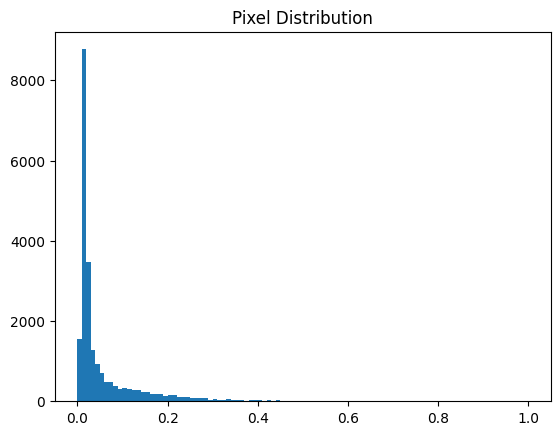

In [36]:
import matplotlib.pyplot as plt

x, _ = train_dataset[0]
x = x.numpy().flatten()

plt.hist(x, bins=100)
plt.title("Pixel Distribution")
plt.show()

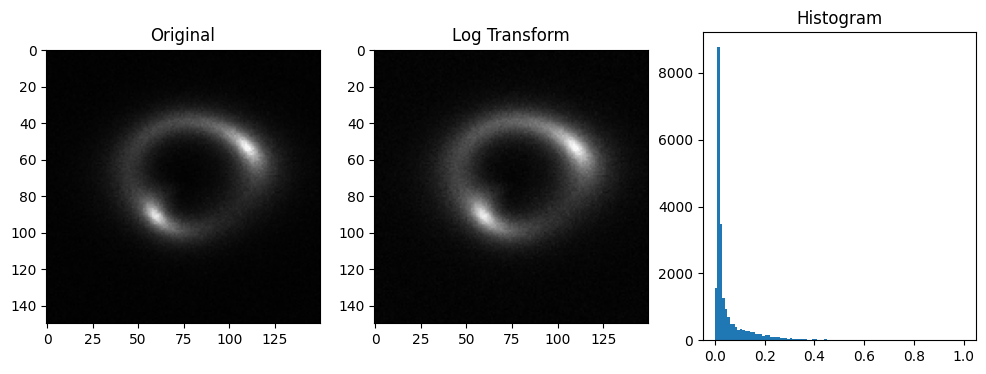

In [37]:
x, _ = train_dataset[0]
x = x.numpy()

log_x = np.log1p(x)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(x[0], cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(log_x[0], cmap='gray')
plt.title("Log Transform")

plt.subplot(1,3,3)
plt.hist(x.flatten(), bins=100)
plt.title("Histogram")

plt.show()